<a href="https://colab.research.google.com/github/mohamedcarab771/personal_information_registration_php/blob/master/finalproject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Load the dataset
df = pd.read_csv('/content/Salaries.csv')

# Display the first 5 rows of the DataFrame
print('First 5 rows of the dataset:')
display(df.head())

# Display basic information about the dataset
print('\nInformation about the dataset:')
df.info()

# Display descriptive statistics of the dataset
print('\nDescriptive statistics of the dataset:')
display(df.describe(include='all'))

# Convert 'salary' into a categorical variable
df['salary_category'] = pd.qcut(df['salary'], q=3, labels=['Low', 'Medium', 'High'])

# Display the value counts of the new target variable
print('\nValue counts of salary_category:')
display(df['salary_category'].value_counts())

# Define features (X) and target (y)
X = df.drop(['salary', 'salary_category'], axis=1)
y = df['salary_category']

# Identify categorical and numerical features
categorical_features = X.select_dtypes(include=['object', 'category']).columns
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns

# Create a column transformer for one-hot encoding categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough' # Keep numerical features as they are
)

# Apply preprocessing and split data
X_processed = preprocessor.fit_transform(X)

# Get feature names after one-hot encoding
cat_encoder = preprocessor.named_transformers_['cat']
encoded_feature_names = cat_encoder.get_feature_names_out(categorical_features)
all_feature_names = list(encoded_feature_names) + list(numerical_features)

X_df = pd.DataFrame(X_processed, columns=all_feature_names)

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_df, y, test_size=0.3, random_state=42, stratify=y)

print('\nShape of X_train:', X_train.shape)
print('Shape of X_test:', X_test.shape)
print('Shape of y_train:', y_train.shape)
print('Shape of y_test:', y_test.shape)
print('\nDistribution of y_train:')
display(y_train.value_counts(normalize=True))
print('\nDistribution of y_test:')
display(y_test.value_counts(normalize=True))

First 5 rows of the dataset:


,rank,discipline,phd,service,sex,salary
0,Prof,B,56,49,Male,186960
1,Prof,A,12,6,Male,93000
2,Prof,A,23,20,Male,110515
3,Prof,A,40,31,Male,131205
4,Prof,B,20,18,Male,104800



Information about the dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78 entries, 0 to 77
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   rank        78 non-null     object
 1   discipline  78 non-null     object
 2   phd         78 non-null     int64 
 3   service     78 non-null     int64 
 4   sex         78 non-null     object
 5   salary      78 non-null     int64 
dtypes: int64(3), object(3)
memory usage: 3.8+ KB

Descriptive statistics of the dataset:


,rank,discipline,phd,service,sex,salary
count,78,78,78.000000,78.000000,78,78.000000
unique,3,2,NaN,NaN,2,NaN
top,Prof,B,NaN,NaN,Male,NaN
freq,46,42,NaN,NaN,39,NaN
mean,NaN,NaN,19.705128,15.051282,NaN,108023.782051
std,NaN,NaN,12.498425,12.139768,NaN,28293.661022
min,NaN,NaN,1.000000,0.000000,NaN,57800.000000
25%,NaN,NaN,10.250000,5.250000,NaN,88612.500000
50%,NaN,NaN,18.500000,14.500000,NaN,104671.000000
75%,NaN,NaN,27.750000,20.750000,NaN,126774.750000



Value counts of salary_category:


,count
salary_category,
Low,28
High,26
Medium,24



Shape of X_train: (54, 9)
Shape of X_test: (24, 9)
Shape of y_train: (54,)
Shape of y_test: (24,)

Distribution of y_train:


,proportion
salary_category,
Low,0.351852
High,0.333333
Medium,0.314815



Distribution of y_test:


,proportion
salary_category,
Low,0.375000
High,0.333333
Medium,0.291667


In [4]:
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_validate
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, make_scorer

print('--- Applying Gaussian Naive Bayes ---')

# Initialize Gaussian Naive Bayes classifier
gnb = GaussianNB()

# Define cross-validation strategy (StratifiedKFold for classification)
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define scoring metrics
scoring = {
    'accuracy': make_scorer(accuracy_score),
    'precision_weighted': make_scorer(precision_score, average='weighted'),
    'recall_weighted': make_scorer(recall_score, average='weighted'),
    'f1_weighted': make_scorer(f1_score, average='weighted')
}

# Perform cross-validation
cv_results = cross_validate(gnb, X_df, y, cv=kf, scoring=scoring, return_train_score=False)

# Report results
print(f"\nGaussian Naive Bayes Cross-Validation Results (5-Fold):")
print(f"  Accuracy: {cv_results['test_accuracy'].mean():.4f} (+/- {cv_results['test_accuracy'].std():.4f})")
print(f"  Precision (weighted): {cv_results['test_precision_weighted'].mean():.4f} (+/- {cv_results['test_precision_weighted'].std():.4f})")
print(f"  Recall (weighted): {cv_results['test_recall_weighted'].mean():.4f} (+/- {cv_results['test_recall_weighted'].std():.4f})")
print(f"  F1-score (weighted): {cv_results['test_f1_weighted'].mean():.4f} (+/- {cv_results['test_f1_weighted'].std():.4f})")

# Train the model on the full training data for potential later use (e.g., specific predictions)
gnb.fit(X_train, y_train)


--- Applying Gaussian Naive Bayes ---

Gaussian Naive Bayes Cross-Validation Results (5-Fold):
  Accuracy: 0.6675 (+/- 0.0692)
  Precision (weighted): 0.7031 (+/- 0.1045)
  Recall (weighted): 0.6675 (+/- 0.0692)
  F1-score (weighted): 0.6410 (+/- 0.0867)


GaussianNB()

In [5]:
from sklearn.neighbors import KNeighborsClassifier

print('\n--- Applying k-Nearest Neighbors (kNN) ---')

# Initialize kNN classifier
knn = KNeighborsClassifier()

# Perform cross-validation
cv_results_knn = cross_validate(knn, X_df, y, cv=kf, scoring=scoring, return_train_score=False)

# Report results
print(f"\nkNN Cross-Validation Results (5-Fold):")
print(f"  Accuracy: {cv_results_knn['test_accuracy'].mean():.4f} (+/- {cv_results_knn['test_accuracy'].std():.4f})")
print(f"  Precision (weighted): {cv_results_knn['test_precision_weighted'].mean():.4f} (+/- {cv_results_knn['test_precision_weighted'].std():.4f})")
print(f"  Recall (weighted): {cv_results_knn['test_recall_weighted'].mean():.4f} (+/- {cv_results_knn['test_recall_weighted'].std():.4f})")
print(f"  F1-score (weighted): {cv_results_knn['test_f1_weighted'].mean():.4f} (+/- {cv_results_knn['test_f1_weighted'].std():.4f})")

# Train the model on the full training data for potential later use
knn.fit(X_train, y_train)


--- Applying k-Nearest Neighbors (kNN) ---

kNN Cross-Validation Results (5-Fold):
  Accuracy: 0.6917 (+/- 0.0637)
  Precision (weighted): 0.7603 (+/- 0.0767)
  Recall (weighted): 0.6917 (+/- 0.0637)
  F1-score (weighted): 0.6877 (+/- 0.0592)


KNeighborsClassifier()

In [6]:
from sklearn.tree import DecisionTreeClassifier

print('\n--- Applying Decision Tree Classifier ---')

# Initialize Decision Tree classifier
dtc = DecisionTreeClassifier(random_state=42)

# Perform cross-validation
cv_results_dtc = cross_validate(dtc, X_df, y, cv=kf, scoring=scoring, return_train_score=False)

# Report results
print(f"\nDecision Tree Cross-Validation Results (5-Fold):")
print(f"  Accuracy: {cv_results_dtc['test_accuracy'].mean():.4f} (+/- {cv_results_dtc['test_accuracy'].std():.4f})")
print(f"  Precision (weighted): {cv_results_dtc['test_precision_weighted'].mean():.4f} (+/- {cv_results_dtc['test_precision_weighted'].std():.4f})")
print(f"  Recall (weighted): {cv_results_dtc['test_recall_weighted'].mean():.4f} (+/- {cv_results_dtc['test_recall_weighted'].std():.4f})")
print(f"  F1-score (weighted): {cv_results_dtc['test_f1_weighted'].mean():.4f} (+/- {cv_results_dtc['test_f1_weighted'].std():.4f})")

# Train the model on the full training data for potential later use
dtc.fit(X_train, y_train)


--- Applying Decision Tree Classifier ---

Decision Tree Cross-Validation Results (5-Fold):
  Accuracy: 0.7158 (+/- 0.0742)
  Precision (weighted): 0.7582 (+/- 0.0521)
  Recall (weighted): 0.7158 (+/- 0.0742)
  F1-score (weighted): 0.7170 (+/- 0.0725)


DecisionTreeClassifier(random_state=42)

In [7]:
from sklearn.svm import SVC

print('\n--- Applying Support Vector Machine (SVM) ---')

# Initialize SVM classifier
svm = SVC(random_state=42)

# Perform cross-validation
cv_results_svm = cross_validate(svm, X_df, y, cv=kf, scoring=scoring, return_train_score=False)

# Report results
print(f"\nSVM Cross-Validation Results (5-Fold):")
print(f"  Accuracy: {cv_results_svm['test_accuracy'].mean():.4f} (+/- {cv_results_svm['test_accuracy'].std():.4f})")
print(f"  Precision (weighted): {cv_results_svm['test_precision_weighted'].mean():.4f} (+/- {cv_results_svm['test_precision_weighted'].std():.4f})")
print(f"  Recall (weighted): {cv_results_svm['test_recall_weighted'].mean():.4f} (+/- {cv_results_svm['test_recall_weighted'].std():.4f})")
print(f"  F1-score (weighted): {cv_results_svm['test_f1_weighted'].mean():.4f} (+/- {cv_results_svm['test_f1_weighted'].std():.4f})")

# Train the model on the full training data for potential later use
svm.fit(X_train, y_train)


--- Applying Support Vector Machine (SVM) ---

SVM Cross-Validation Results (5-Fold):
  Accuracy: 0.6917 (+/- 0.0306)
  Precision (weighted): 0.7576 (+/- 0.0630)
  Recall (weighted): 0.6917 (+/- 0.0306)
  F1-score (weighted): 0.6805 (+/- 0.0202)


SVC(random_state=42)

In [8]:
from sklearn.ensemble import RandomForestClassifier

print('\n--- Applying Random Forest Classifier ---')

# Initialize Random Forest classifier
rfc = RandomForestClassifier(random_state=42)

# Perform cross-validation
cv_results_rfc = cross_validate(rfc, X_df, y, cv=kf, scoring=scoring, return_train_score=False)

# Report results
print(f"\nRandom Forest Cross-Validation Results (5-Fold):")
print(f"  Accuracy: {cv_results_rfc['test_accuracy'].mean():.4f} (+/- {cv_results_rfc['test_accuracy'].std():.4f})")
print(f"  Precision (weighted): {cv_results_rfc['test_precision_weighted'].mean():.4f} (+/- {cv_results_rfc['test_precision_weighted'].std():.4f})")
print(f"  Recall (weighted): {cv_results_rfc['test_recall_weighted'].mean():.4f} (+/- {cv_results_rfc['test_recall_weighted'].std():.4f})")
print(f"  F1-score (weighted): {cv_results_rfc['test_f1_weighted'].mean():.4f} (+/- {cv_results_rfc['test_f1_weighted'].std():.4f})")

# Train the model on the full training data for potential later use
rfc.fit(X_train, y_train)


--- Applying Random Forest Classifier ---

Random Forest Cross-Validation Results (5-Fold):
  Accuracy: 0.7042 (+/- 0.0550)
  Precision (weighted): 0.7480 (+/- 0.0678)
  Recall (weighted): 0.7042 (+/- 0.0550)
  F1-score (weighted): 0.7069 (+/- 0.0546)


RandomForestClassifier(random_state=42)

In [9]:
from sklearn.linear_model import LogisticRegression

print('\n--- Applying Logistic Regression ---')

# Initialize Logistic Regression classifier
lr = LogisticRegression(random_state=42, solver='liblinear', multi_class='ovr')

# Perform cross-validation
cv_results_lr = cross_validate(lr, X_df, y, cv=kf, scoring=scoring, return_train_score=False)

# Report results
print(f"\nLogistic Regression Cross-Validation Results (5-Fold):")
print(f"  Accuracy: {cv_results_lr['test_accuracy'].mean():.4f} (+/- {cv_results_lr['test_accuracy'].std():.4f})")
print(f"  Precision (weighted): {cv_results_lr['test_precision_weighted'].mean():.4f} (+/- {cv_results_lr['test_precision_weighted'].std():.4f})")
print(f"  Recall (weighted): {cv_results_lr['test_recall_weighted'].mean():.4f} (+/- {cv_results_lr['test_recall_weighted'].std():.4f})")
print(f"  F1-score (weighted): {cv_results_lr['test_f1_weighted'].mean():.4f} (+/- {cv_results_lr['test_f1_weighted'].std():.4f})")

# Train the model on the full training data for potential later use
lr.fit(X_train, y_train)


--- Applying Logistic Regression ---


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was depre


Logistic Regression Cross-Validation Results (5-Fold):
  Accuracy: 0.7558 (+/- 0.0293)
  Precision (weighted): 0.8078 (+/- 0.0508)
  Recall (weighted): 0.7558 (+/- 0.0293)
  F1-score (weighted): 0.7526 (+/- 0.0315)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(multi_class='ovr', random_state=42, solver='liblinear')

In [10]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

print('\n--- Applying Linear Discriminant Analysis (LDA) ---')

# Initialize LDA classifier
lda = LinearDiscriminantAnalysis()

# Perform cross-validation
cv_results_lda = cross_validate(lda, X_df, y, cv=kf, scoring=scoring, return_train_score=False)

# Report results
print(f"\nLDA Cross-Validation Results (5-Fold):")
print(f"  Accuracy: {cv_results_lda['test_accuracy'].mean():.4f} (+/- {cv_results_lda['test_accuracy'].std():.4f})")
print(f"  Precision (weighted): {cv_results_lda['test_precision_weighted'].mean():.4f} (+/- {cv_results_lda['test_precision_weighted'].std():.4f})")
print(f"  Recall (weighted): {cv_results_lda['test_recall_weighted'].mean():.4f} (+/- {cv_results_lda['test_recall_weighted'].std():.4f})")
print(f"  F1-score (weighted): {cv_results_lda['test_f1_weighted'].mean():.4f} (+/- {cv_results_lda['test_f1_weighted'].std():.4f})")

# Train the model on the full training data for potential later use
lda.fit(X_train, y_train)


--- Applying Linear Discriminant Analysis (LDA) ---

LDA Cross-Validation Results (5-Fold):
  Accuracy: 0.7808 (+/- 0.0554)
  Precision (weighted): 0.8235 (+/- 0.0496)
  Recall (weighted): 0.7808 (+/- 0.0554)
  F1-score (weighted): 0.7829 (+/- 0.0546)


LinearDiscriminantAnalysis()


--- Comparative Analysis of Algorithms (Accuracy Boxplot) ---


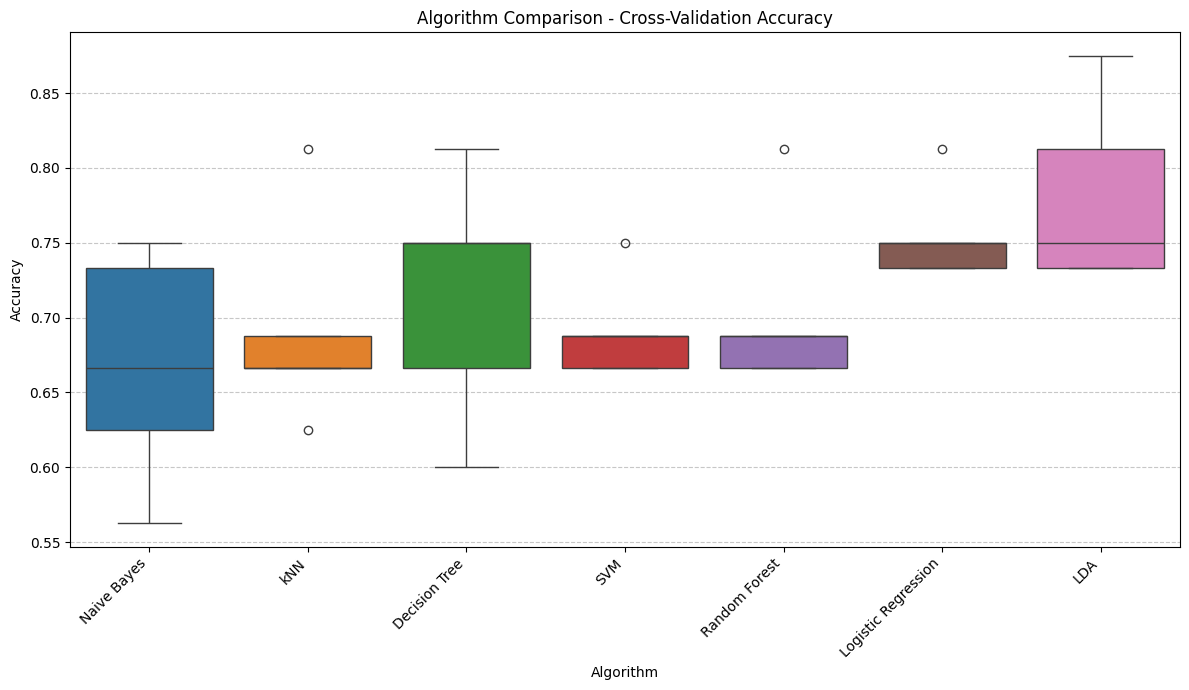

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Store the cross-validation results for each model
results = {
    'Naive Bayes': cv_results['test_accuracy'],
    'kNN': cv_results_knn['test_accuracy'],
    'Decision Tree': cv_results_dtc['test_accuracy'],
    'SVM': cv_results_svm['test_accuracy'],
    'Random Forest': cv_results_rfc['test_accuracy'],
    'Logistic Regression': cv_results_lr['test_accuracy'],
    'LDA': cv_results_lda['test_accuracy']
}

# Convert results to a DataFrame for easier plotting
results_df = pd.DataFrame(results)

print('\n--- Comparative Analysis of Algorithms (Accuracy Boxplot) ---')

# Create a boxplot to compare the algorithms
plt.figure(figsize=(12, 7))
sns.boxplot(data=results_df)
plt.title('Algorithm Comparison - Cross-Validation Accuracy')
plt.xlabel('Algorithm')
plt.ylabel('Accuracy')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [12]:
print('\n--- Mean Accuracy for Each Model ---')
mean_accuracies = results_df.mean()
display(mean_accuracies)


--- Mean Accuracy for Each Model ---


,0
Naive Bayes,0.667500
kNN,0.691667
Decision Tree,0.715833
SVM,0.691667
Random Forest,0.704167
Logistic Regression,0.755833
LDA,0.780833


In [13]:
print('\n--- Comprehensive Performance Metrics (Mean) ---')

# Dictionary to store mean of all metrics for each model
all_metrics_mean = {}

# Collect mean metrics for Naive Bayes
all_metrics_mean['Naive Bayes'] = {
    'Accuracy': cv_results['test_accuracy'].mean(),
    'Precision': cv_results['test_precision_weighted'].mean(),
    'Recall': cv_results['test_recall_weighted'].mean(),
    'F1-score': cv_results['test_f1_weighted'].mean()
}

# Collect mean metrics for kNN
all_metrics_mean['kNN'] = {
    'Accuracy': cv_results_knn['test_accuracy'].mean(),
    'Precision': cv_results_knn['test_precision_weighted'].mean(),
    'Recall': cv_results_knn['test_recall_weighted'].mean(),
    'F1-score': cv_results_knn['test_f1_weighted'].mean()
}

# Collect mean metrics for Decision Tree
all_metrics_mean['Decision Tree'] = {
    'Accuracy': cv_results_dtc['test_accuracy'].mean(),
    'Precision': cv_results_dtc['test_precision_weighted'].mean(),
    'Recall': cv_results_dtc['test_recall_weighted'].mean(),
    'F1-score': cv_results_dtc['test_f1_weighted'].mean()
}

# Collect mean metrics for SVM
all_metrics_mean['SVM'] = {
    'Accuracy': cv_results_svm['test_accuracy'].mean(),
    'Precision': cv_results_svm['test_precision_weighted'].mean(),
    'Recall': cv_results_svm['test_recall_weighted'].mean(),
    'F1-score': cv_results_svm['test_f1_weighted'].mean()
}

# Collect mean metrics for Random Forest
all_metrics_mean['Random Forest'] = {
    'Accuracy': cv_results_rfc['test_accuracy'].mean(),
    'Precision': cv_results_rfc['test_precision_weighted'].mean(),
    'Recall': cv_results_rfc['test_recall_weighted'].mean(),
    'F1-score': cv_results_rfc['test_f1_weighted'].mean()
}

# Collect mean metrics for Logistic Regression
all_metrics_mean['Logistic Regression'] = {
    'Accuracy': cv_results_lr['test_accuracy'].mean(),
    'Precision': cv_results_lr['test_precision_weighted'].mean(),
    'Recall': cv_results_lr['test_recall_weighted'].mean(),
    'F1-score': cv_results_lr['test_f1_weighted'].mean()
}

# Collect mean metrics for LDA
all_metrics_mean['LDA'] = {
    'Accuracy': cv_results_lda['test_accuracy'].mean(),
    'Precision': cv_results_lda['test_precision_weighted'].mean(),
    'Recall': cv_results_lda['test_recall_weighted'].mean(),
    'F1-score': cv_results_lda['test_f1_weighted'].mean()
}

# Convert the dictionary to a DataFrame for display
metrics_df = pd.DataFrame(all_metrics_mean).T
metrics_df.index.name = 'Model'
display(metrics_df)


--- Comprehensive Performance Metrics (Mean) ---


,Accuracy,Precision,Recall,F1-score
Model,,,,
Naive Bayes,0.667500,0.703131,0.667500,0.641025
kNN,0.691667,0.760251,0.691667,0.687659
Decision Tree,0.715833,0.758178,0.715833,0.717001
SVM,0.691667,0.757573,0.691667,0.680477
Random Forest,0.704167,0.747951,0.704167,0.706910
Logistic Regression,0.755833,0.807801,0.755833,0.752634
LDA,0.780833,0.823547,0.780833,0.782881



--- Heatmap of Performance Metrics ---


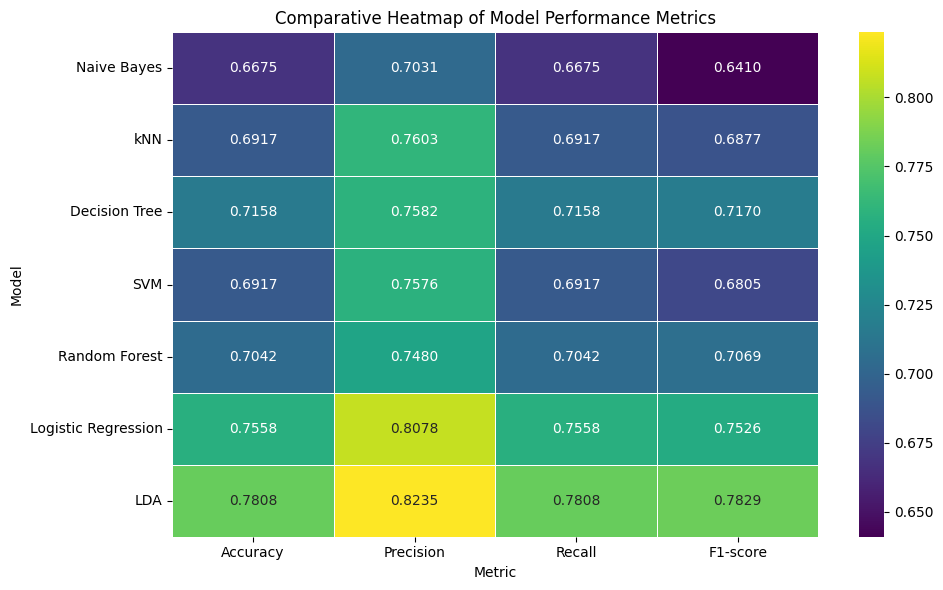

In [14]:
print('\n--- Heatmap of Performance Metrics ---')

plt.figure(figsize=(10, 6))
sns.heatmap(metrics_df, annot=True, cmap='viridis', fmt=".4f", linewidths=.5)
plt.title('Comparative Heatmap of Model Performance Metrics')
plt.xlabel('Metric')
plt.ylabel('Model')
plt.tight_layout()
plt.show()

In [15]:
import joblib

# Define a filename for the model
model_filename = 'lda_best_model.joblib'

# Save the trained LDA model to the file
joblib.dump(lda, model_filename)

print(f"Best performing LDA model saved to {model_filename}")

Best performing LDA model saved to lda_best_model.joblib


In [16]:
import joblib

# Define the filename of the saved model
model_filename = 'lda_best_model.joblib'

# Load the model back into a variable
loaded_lda_model = joblib.load(model_filename)

print(f"Model '{model_filename}' loaded successfully!")

# You can now use the loaded_lda_model for predictions or further analysis
# For example, let's make a prediction on the first sample from X_test
sample_to_predict = X_test.iloc[[0]]
prediction = loaded_lda_model.predict(sample_to_predict)

print(f"Prediction for the first test sample: {prediction[0]}")
print(f"Actual value for the first test sample: {y_test.iloc[0]}")

Model 'lda_best_model.joblib' loaded successfully!
Prediction for the first test sample: Low
Actual value for the first test sample: Low


In [17]:
from google.colab import files

files.download('lda_best_model.joblib')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>